In [27]:
# Import libraries and define helper functions
import networkx as nx 
import pandas as pd 
from pathlib import Path
import numpy as np
import math

# Define angle calculation functions
def angle_from_center(x, y, center_x=0.5, center_y=0.5):
    """Calculate angle from center point to (x,y) relative to positive X-axis [0,360)."""
    ang = math.degrees(math.atan2(y - center_y, x - center_x))
    if ang < 0:
        ang += 360.0
    return ang

def angular_difference(angle1, angle2):
    """Calculate minimum angular difference between two angles [0,180]."""
    diff = abs(angle1 - angle2)
    return min(diff, 360.0 - diff)

def circular_mean_deg(angles_deg):
    """Return circular mean (degrees [0,360)) or None if undefined/empty."""
    if len(angles_deg) == 0:
        return None
    a = np.deg2rad(np.array(angles_deg, dtype=float))
    s, c = np.sin(a).sum(), np.cos(a).sum()
    # if vector sum is essentially zero -> undefined mean
    if np.isclose(s, 0.0) and np.isclose(c, 0.0):
        return None
    mean_ang = math.degrees(math.atan2(s, c))
    if mean_ang < 0:
        mean_ang += 360.0
    return mean_ang

# setting the directory path
data_dir = Path('/Users/xiongjiaqi/Desktop/OII_SDS/FSDS/week2/Network Canvas Export Tables') 

# Load and process the data (same as in week3exercise)
def load_csv_files(pattern):
    dfs = []
    for file in data_dir.glob(pattern):
        df = pd.read_csv(file)
        df['source_file'] = file.name
        dfs.append(df)
    
    if dfs:
        return pd.concat(dfs, ignore_index=True)
    return None

# Load different types of files
attr_df = load_csv_files("*_attributeList_concept.csv")
ego_df = load_csv_files("*_ego.csv")

# Get SessionID
attr_df['SessionID'] = attr_df['source_file'].str.extract(r'Anonymous Participant_([\w]+)_attributeList_concept\.csv')
ego_df['SessionID'] = ego_df['source_file'].str.extract(r'Anonymous Participant_([\w]+)_ego\.csv')

# Merge
df_alter = pd.merge(attr_df, ego_df, on='SessionID', suffixes=('_attr', '_ego'))
print(f"Loaded {len(df_alter)} rows, {df_alter['SessionID'].nunique()} sessions, {df_alter['name'].nunique()} concepts")


Loaded 186 rows, 17 sessions, 38 concepts


In [28]:
# Step 1: Filter to only ego spaces (sessions) that contain "AI"
sessions_with_ai = df_alter[df_alter['name'] == 'technology']['SessionID'].unique()
df_alter_with_ai = df_alter[df_alter['SessionID'].isin(sessions_with_ai)].copy()
print(f"Filtered to {len(sessions_with_ai)} sessions with 'technology' ({len(df_alter_with_ai)} rows)")


Filtered to 11 sessions with 'technology' (116 rows)


In [29]:
# Step 2: Calculate angles between AI and every other component in each session
angle_records = []

for session_id in sessions_with_ai:
    session_data = df_alter_with_ai[df_alter_with_ai['SessionID'] == session_id]
    ai_data = session_data[session_data['name'] == 'technology']
    
    if len(ai_data) == 0:
        continue
    
    # Calculate AI's angle from center relative to X-axis
    ai_x, ai_y = ai_data['user_layout_x'].values[0], ai_data['user_layout_y'].values[0]
    ai_angle = angle_from_center(ai_x, ai_y)
    
    for idx, row in session_data.iterrows():
        # if row['name'] == 'AI':
        #     continue
        
        # Calculate concept's angle from center relative to X-axis
        concept_angle = angle_from_center(row['user_layout_x'], row['user_layout_y'])
        
        # Calculate angular difference (0-180)
        angle = angular_difference(ai_angle, concept_angle)
        
        angle_records.append({
            'session_id': session_id,
            'concept': row['name'],
            'angle_deg': angle
        })

df_ai_angles = pd.DataFrame(angle_records)
print(f"Calculated {len(df_ai_angles)} angle measurements")
df_ai_angles.head(10)


Calculated 116 angle measurements


,session_id,concept,angle_deg
0,cmh20p3iy0027sa27jqf9dcog,AI,86.892724
1,cmh20p3iy0027sa27jqf9dcog,community,142.428338
2,cmh20p3iy0027sa27jqf9dcog,culture,36.080013
3,cmh20p3iy0027sa27jqf9dcog,freedom,144.351102
4,cmh20p3iy0027sa27jqf9dcog,identity,91.875826
5,cmh20p3iy0027sa27jqf9dcog,perspective,45.225386
6,cmh20p3iy0027sa27jqf9dcog,social norms,38.328150
7,cmh20p3iy0027sa27jqf9dcog,technology,0.000000
8,cmh20p3iy0027sa27jqf9dcog,truth,50.721706
9,cmh20p3iy0027sa27jqf9dcog,social networks,32.475872


In [30]:
# Step 3: Save detailed results to CSV
df_ai_angles.to_csv('ai_component_angles_detailed.csv', index=False)
print(f"Saved detailed angles ({df_ai_angles['concept'].nunique()} unique concepts)")


Saved detailed angles (34 unique concepts)


In [31]:
# Step 4: Calculate mean angle for each concept with AI (in radians)
summary_records = []

for concept in df_ai_angles['concept'].unique():
    concept_angles = df_ai_angles[df_ai_angles['concept'] == concept]['angle_deg'].values
    
    # For angular differences (0-180), use simple mean
    mean_angle_deg = np.mean(concept_angles)
    mean_angle_rad = np.deg2rad(mean_angle_deg)
    
    summary_records.append({
        'concept': concept,
        'occurrence_count': len(concept_angles),
        'mean_angle_rad': mean_angle_rad,
        'mean_angle_deg': mean_angle_deg,
        'angle_std': np.std(concept_angles)
    })

df_ai_summary = pd.DataFrame(summary_records).sort_values('occurrence_count', ascending=False).reset_index(drop=True)

# No normalization - keep original 0-180° range for upper half circle visualization
df_ai_summary.to_csv('ai_component_angles_summary.csv', index=False)
max_angle = df_ai_summary['mean_angle_deg'].max()
print(f"Saved summary. Angles in 0-180° range (max: {max_angle:.2f}°) for upper half circle plot")
df_ai_summary


Saved summary. Angles in 0-180° range (max: 144.35°) for upper half circle plot


,concept,occurrence_count,mean_angle_rad,mean_angle_deg,angle_std
0,technology,11,0.000000,0.000000,0.000000
1,AI,10,1.491316,85.446105,55.990473
2,knowledge,7,2.136540,122.414710,32.905644
3,empirical data,6,1.594058,91.332794,51.077776
4,ethics,6,1.369719,78.479134,52.264250
5,theory,5,2.134688,122.308621,48.726756
6,analysis,5,1.348538,77.265554,40.251990
7,context,4,1.295454,74.224035,48.407972
8,structure,4,2.130261,122.054990,31.980921
9,policy,4,1.572481,90.096506,69.588493


In [32]:
# Load and merge with AI angles, then normalize to 0-180°
df_concepts_all = pd.read_csv('concepts_summary_all.csv')

# Merge with AI angle data
df_concepts_all = df_concepts_all.merge(
    df_ai_summary[['concept', 'mean_angle_deg', 'occurrence_count', 'angle_std']], 
    left_on='name', 
    right_on='concept', 
    how='left',
    suffixes=('_orig', '_ai')
)

# Replace angles with AI-relative angles (if available)
df_concepts_all['mean_angle_deg'] = df_concepts_all['mean_angle_deg_ai'].fillna(df_concepts_all['mean_angle_deg_orig'])

# Normalize to 0-180° (stretch max to 180°)
max_angle = df_concepts_all['mean_angle_deg'].max()
df_concepts_all['mean_angle_deg_normalized'] = (df_concepts_all['mean_angle_deg'] / max_angle) * 180
df_concepts_all['mean_angle_rad_normalized'] = np.deg2rad(df_concepts_all['mean_angle_deg_normalized'])

# Mark which have AI angles
df_concepts_all['has_ai_angle'] = df_concepts_all['mean_angle_deg_ai'].notna()

# Clean up
df_concepts_all = df_concepts_all.drop(columns=['concept', 'mean_angle_deg_orig', 'mean_angle_deg_ai'], errors='ignore')

print(f"✅ Loaded {len(df_concepts_all)} concepts")
print(f"   Max angle: {max_angle:.2f}° → normalized to 180°")
print(f"   With AI angles: {df_concepts_all['has_ai_angle'].sum()}")
df_concepts_all[['name', 'mean_angle_deg', 'mean_angle_deg_normalized']].head(5)


✅ Loaded 37 concepts
   Max angle: 179.95° → normalized to 180°
   With AI angles: 33


,name,mean_angle_deg,mean_angle_deg_normalized
0,AI,85.446105,85.468526
1,technology,0.000000,0.000000
2,ethics,78.479134,78.499726
3,knowledge,122.414710,122.446830
4,analysis,77.265554,77.285828


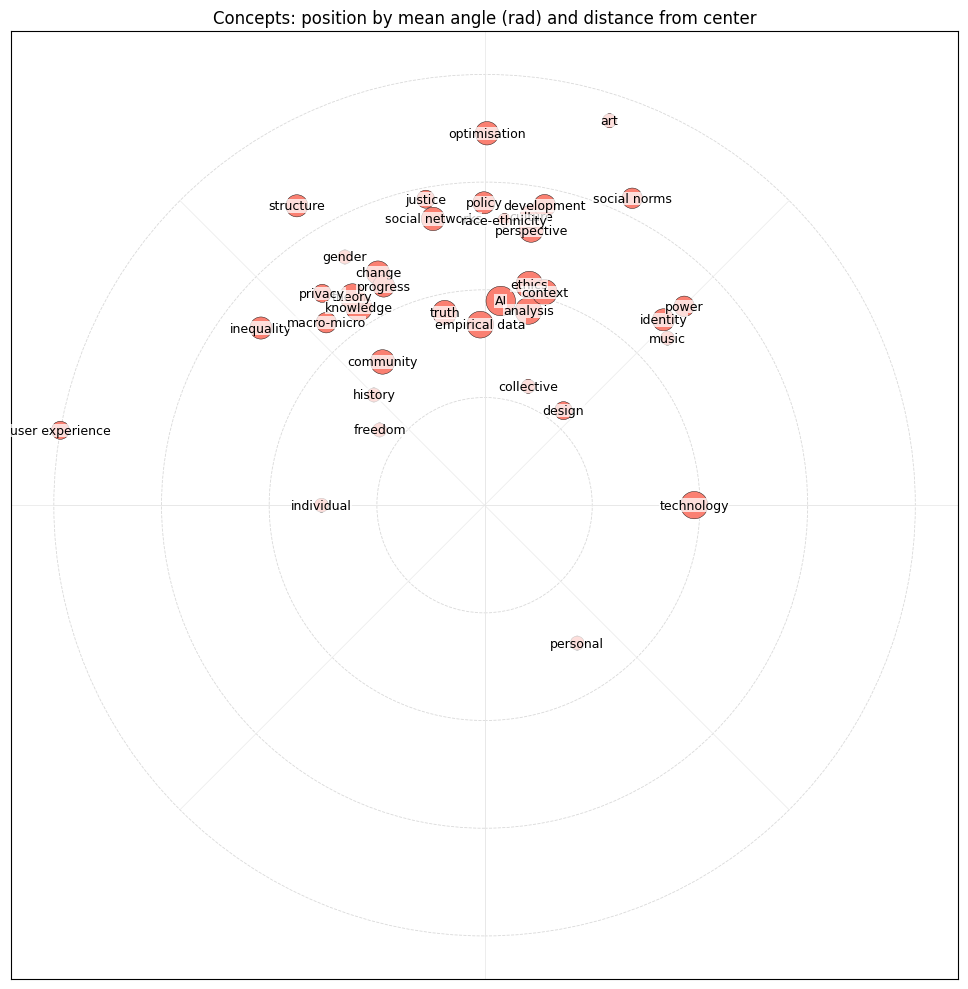

Plotted 37 concepts. Saved to concepts_circular_map.png


In [33]:
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
DF = df_concepts_all            # your final dataframe, indexed by concept name
ANGLE_COL = 'mean_angle_rad_normalized'    # radians
DIST_COL = 'distance'           # euclidean distance from center (already computed)
FREQ_COL = 'concept_count'
#RESULTANT_COL = 'resultant_length'   # optional: concentration of angles (0..1)
FIGSIZE = (10,10)
SAVE_PATH = 'concepts_circular_map.png'
GUIDE_CIRCLES = True
MAX_LABELS = None   # None = label all; or set int to label top-N by frequency
# -----------------------------

# --- Basic checks ---
if ANGLE_COL not in DF.columns and ANGLE_COL not in DF.index:
    raise KeyError(f"Angle column '{ANGLE_COL}' not found in df_concepts_all. Columns: {list(DF.columns)}")
if DIST_COL not in DF.columns:
    raise KeyError(f"Distance column '{DIST_COL}' not found in df_concepts_all. Columns: {list(DF.columns)}")

# ensure index is name
df = DF.copy()
if df.index.name != 'name' and 'name' in df.columns:
    df = df.set_index('name')

# select and drop missing rows
cols_needed = [ANGLE_COL, DIST_COL]
df_plot = df[cols_needed + [c for c in ([FREQ_COL]) if c in df.columns]].copy()
df_plot = df_plot.dropna(subset=[ANGLE_COL, DIST_COL])

# extract plotting arrays
thetas = df_plot[ANGLE_COL].astype(float).values   # radians
rs     = df_plot[DIST_COL].astype(float).values

# polar -> cartesian (center at 0,0)
xs = rs * np.cos(thetas)
ys = rs * np.sin(thetas)
df_plot['_x'] = xs
df_plot['_y'] = ys


# marker sizes based on log(concept_count)
if 'concept_count' not in df_plot.columns:
    raise KeyError("'concept_count' column not found in df_concepts_all.")

# compute log-scaled sizes (add 1 to avoid log(0))
freq = np.log1p(df_plot['concept_count'].astype(float))

# normalize to a visual range (e.g., 40–420)
s_min, s_max = 100, 450
if freq.max() == freq.min():
    sizes = np.full_like(freq, (s_min + s_max) / 2)
else:
    sizes = s_min + (freq - freq.min()) / (freq.max() - freq.min()) * (s_max - s_min)

"""# marker sizes: scale by best available freq column or constant
freq_col = next((c for c in FREQ_COL if c in df_plot.columns), None)
if freq_col:
    freq = df_plot[freq_col].astype(float).fillna(0)
    s_min, s_max = 40, 420
    if freq.max() == freq.min():
        sizes = np.full_like(freq, (s_min+s_max)/2)
    else:
        sizes = s_min + (freq - freq.min())/(freq.max()-freq.min())*(s_max-s_min)
else:
    sizes = np.full(len(df_plot), 120)"""

# Use one color for all nodes
colors = 'salmon'      # or any Matplotlib color name, e.g. 'gray', 'crimson', '#1f77b4'
colorbar_label = None     # no colorbar needed

"""# colors: use resultant_length if present else single color
if RESULTANT_COL in df_plot.columns:
    vals = df_plot[RESULTANT_COL].astype(float).fillna(0)
    cmap = plt.get_cmap('viridis')
    normed = (vals - vals.min()) / (vals.max() - vals.min() + 1e-12)
    colors = cmap(normed)
    colorbar_label = 'resultant_length (angle concentration)'
else:
    colors = 'C0'
    colorbar_label = None"""

# choose labels (optionally top-N by freq)
if MAX_LABELS and freq_col:
    label_idx = df_plot.sort_values(freq_col, ascending=False).head(MAX_LABELS).index
elif MAX_LABELS:
    label_idx = df_plot.index[:MAX_LABELS]
else:
    label_idx = df_plot.index

# --- Plot ---
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.set_aspect('equal')

# scatter nodes
scatter = ax.scatter(df_plot['_x'], df_plot['_y'], s=sizes, c=colors, edgecolor='k', linewidth=0.3, zorder=3)

# guide circles and radial lines
if GUIDE_CIRCLES:
    max_r = np.nanmax(rs) if len(rs)>0 else 1.0
    circles = np.linspace(0, max_r, 5)[1:]
    for r in circles:
        ax.add_artist(plt.Circle((0,0), r, color='0.85', fill=False, linestyle='--', linewidth=0.6, zorder=0))
    for deg in range(0, 360, 45):
        theta = np.deg2rad(deg)
        ax.plot([0, max_r*np.cos(theta)], [0, max_r*np.sin(theta)], color='0.93', linewidth=0.6, zorder=0)

# labels
for name in label_idx:
    row = df_plot.loc[name]
    ax.text(row['_x'], row['_y'], str(name), fontsize=9, ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=0.2), zorder=4)

# optional colorbar
if colorbar_label:
    import matplotlib as mpl
    norm = mpl.colors.Normalize(vmin=vals.min(), vmax=vals.max())
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(colorbar_label)

# cosmetics (center intentionally left empty)
ax.axhline(0, color='0.9', linewidth=0.5)
ax.axvline(0, color='0.9', linewidth=0.5)
ax.set_title('Concepts: position by mean angle (rad) and distance from center')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=300)
plt.show()

print(f"Plotted {len(df_plot)} concepts. Saved to {SAVE_PATH}")
